# CNN for Flower Dataset

## 載入模組

In [ ]:
import math, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms

## 載入 CIFAR10 資料集

In [2]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑

In [3]:
batch_size = 100

# 標準化
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_data = datasets.CIFAR10(PATH_DATASETS, train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(PATH_DATASETS, train=False, download=True, transform=transform)

## 資料分割

In [4]:
test_size = 0.2
idx = list(range(len(train_data)))
np.random.shuffle(idx)
split_size = int(np.floor(test_size * len(train_data)))
train_idx, dev_idx = idx[split_size:], idx[:split_size]

train_sampler = SubsetRandomSampler(train_idx)
dev_sampler = SubsetRandomSampler(dev_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler)
dev_loader = DataLoader(train_data, batch_size=batch_size, sampler=dev_sampler)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [5]:
# 圖片的維度：顏色通道、寬、高
train_data[0][0].shape

torch.Size([3, 32, 32])

## GPU / CPU 判斷

In [6]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 計算Conv2D/Pool2D 轉換後的圖片寬度

In [7]:
# W, F, P, S：image Width, Filter width, Padding, Stride
# def Conv_Width(W, F, P, S):
#     return math.floor(((W - F) + 2 * P) / S) + 1

# def Pool_Width(W, F, S):
#     return math.floor((W - F) / S) + 1


def Conv_Width(W, F, P, S):
    return math.floor(((W - F + 2 * P) / S) + 1)


def Pool_Width(W, F, S):
    return math.floor((W - F) / S + 1)


# test
print(Pool_Width(Conv_Width(32, 3, 1, 1), 2, 2))
print(Pool_Width(Conv_Width(16, 3, 1, 1), 2, 2))
print(Pool_Width(Conv_Width(8, 3, 1, 1), 2, 2))


def Conv_Pool_Width(W, F, P, S, F2, S2, n):
    for i in range(n):
        W = Pool_Width(Conv_Width(W, F, P, S), F2, S2)
    return W


Conv_Pool_Width(32, 3, 1, 1, 2, 2, 3)

16
8
4


4

## 建立神經網路模型

In [8]:
Adjusted_width = Conv_Pool_Width(32, 3, 1, 1, 2, 2, 3)


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Conv2d 參數： in-channel, out-channel, kernel size, Padding, Stride
        self.conv1 = nn.Conv2d(3, 10, 3, 1, 1)
        self.conv2 = nn.Conv2d(10, 20, 3, 1, 1)
        self.conv3 = nn.Conv2d(20, 40, 3, 1, 1)
        self.pool = nn.MaxPool2d(2, 2)

        self.linear1 = nn.Linear(40 * Adjusted_width * Adjusted_width, 100)
        self.linear2 = nn.Linear(100, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x: torch.Tensor):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # flatten
        x = x.view(-1, 40 * Adjusted_width * Adjusted_width)

        x = self.dropout(x)
        x = F.relu(self.linear1(x))
        x = self.dropout(x)
        x = F.log_softmax(self.linear2(x), dim=1)

        return x

## 定義損失函數、優化器

In [9]:
model = CNN().to(device)
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

## 訓練模型

In [ ]:
train_losses, dev_losses, train_acc, dev_acc = [], [], [], []
x_axis = []

for e in range(1, epochs + 1):
    losses = 0
    acc = 0
    iterations = 0

    model.train()
    data: torch.Tensor
    target: torch.Tensor
    for data, target in train_loader:
        iterations += 1

        pred = model(data.to(device))
        loss = loss_function.forward(pred, target.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses += loss.item()
        p = torch.exp(pred)
        top_p, top_class = p.topk(1, dim=1)
        acc += accuracy_score(target.to("cpu"), top_class.to("cpu"))

    dev_losss = 0
    dev_accs = 0
    iter_2 = 0

    if e % 5 == 0 or e == 1:
        x_axis.append(e)

        model.eval()
        with torch.no_grad():

            data_dev: torch.Tensor
            target_dev: torch.Tensor
            for data_dev, target_dev in dev_loader:
                iter_2 += 1

                dev_pred = model(data_dev.to(device))
                dev_loss = loss_function.forward(dev_pred, target_dev.to(device))
                dev_losss += dev_loss.item()

                dev_p = torch.exp(dev_pred)
                top_p, dev_top_class = dev_p.topk(1, dim=1)
                dev_accs += accuracy_score(target_dev.to("cpu"), dev_top_class.to("cpu"))

        train_losses.append(losses / iterations)
        dev_losses.append(dev_losss / iter_2)
        train_acc.append(acc / iterations)
        dev_acc.append(dev_accs / iter_2)

        print(
            f"Epoch: {e}/{epochs}  "
            f"Training Loss: {losses / iterations:.3f}  "
            f"Validation Loss: {dev_losss / iter_2:.3f}  "
            f"Training Accuracy: {acc / iterations:.3f}  "
            f"Validation Accuracy: {dev_accs / iter_2:.3f}"
        )

## 損失函數畫圖

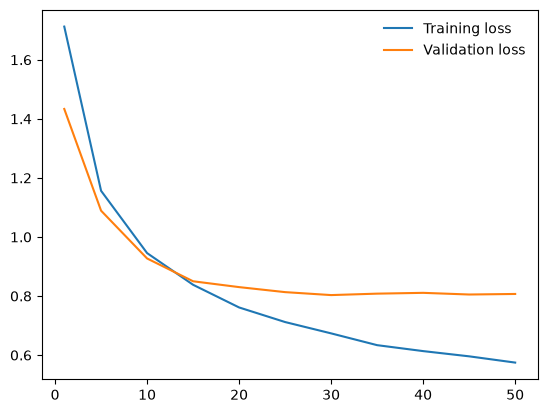

In [11]:
plt.plot(x_axis, train_losses, label='Training loss')
plt.plot(x_axis, dev_losses, label='Validation loss')
plt.legend(frameon=False)
plt.show()

## 準確率畫圖

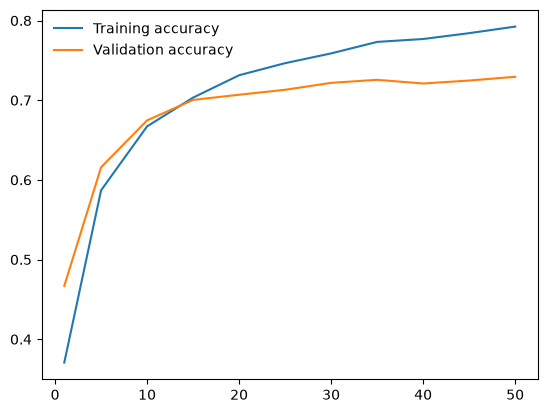

In [12]:
plt.plot(x_axis, train_acc, label="Training accuracy")
plt.plot(x_axis, dev_acc, label="Validation accuracy")
plt.legend(frameon=False)
plt.show()

## 模型評估

In [13]:
model.eval()
no = 0
acc_test = 0
data_test: torch.Tensor
target_test: torch.Tensor
for data_test, target_test in test_loader:
    no += 1
    test_pred = model(data_test.to(device))
    test_pred = torch.exp(test_pred)
    top_p, top_class_test = test_pred.topk(1, dim=1)
    # sklearn 只能在 cpu 計算
    acc_test += accuracy_score(target_test.to("cpu"), top_class_test.to("cpu"))

print('Test Accuracy: %.2f' % (acc_test * 100 / no))

Test Accuracy: 72.50


## 模型評估 方法2

In [14]:
# compute accuracy
def get_accuracy(logit, target):
    '''Obtain accuracy for training round'''
    batch_size = len(target)
    #     corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    corrects = (torch.max(logit, 1)[1].data == target.data).sum()
    accuracy = 100.0 * corrects / batch_size
    return accuracy.item()

In [15]:
no = 0
acc_test = 0
data_test: torch.Tensor
target_test: torch.Tensor
for data_test, target_test in test_loader:
    no += 1
    test_pred = model(data_test.to(device))
    acc_test += get_accuracy(test_pred, target_test.to(device))

print('Test Accuracy: %.2f' % (acc_test / no))

Test Accuracy: 72.50
